In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/My Drive'

Mounted at /content/drive
/content/drive/My Drive


In [2]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, roc_curve, auc

class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]), initializer='random_normal', trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],), initializer='zeros', trainable=True)

    def call(self, inputs):
        attention_scores = tf.matmul(inputs, self.W) + self.b
        attention_scores = tf.nn.softmax(attention_scores, axis=-1)
        return tf.multiply(inputs, attention_scores)

def DualAttention_FERNet(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)

    x1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x1 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = AttentionLayer()(x1)
    x1 = layers.Dropout(0.3)(x1)
    x1 = layers.Flatten()(x1)
    x1 = layers.Dense(128, activation='relu')(x1)
    x1 = layers.Dropout(0.3)(x1)

    x2 = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(input_layer)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling2D((2, 2))(x2)
    x2 = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling2D((2, 2))(x2)
    x2 = layers.Conv2D(128, (5, 5), activation='relu', padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = AttentionLayer()(x2)
    x2 = layers.Dropout(0.3)(x2)
    x2 = layers.Flatten()(x2)
    x2 = layers.Dense(128, activation='relu')(x2)
    x2 = layers.Dropout(0.3)(x2)

    combined = layers.concatenate([x1, x2])

    combined = layers.Dense(128, activation='relu')(combined)
    combined = layers.BatchNormalization()(combined)
    output = layers.Dense(num_classes, activation='softmax')(combined)

    model = models.Model(inputs=input_layer, outputs=output)
    return model

data = np.load('/content/drive/My Drive/face.npz')
x_train = data['x_train']
x_test = data['x_test']
y_train = data['y_train']
y_test = data['y_test']

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

input_shape = x_train.shape[1:]
num_classes = 7
model = DualAttention_FERNet(input_shape, num_classes)

model.summary()
print(f"Total parameters in the model: {model.count_params()}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 48, 48, 1)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 48, 48, 32)     │            320 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 48, 48, 32)     │            832 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 48, 48, 32)     │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 48, 48, 32)     │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 24, 24, 32)     │              0 │ batch_normalization[0… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 24, 24, 32)     │              0 │ batch_normalization_3… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 24, 24, 64)     │         18,496 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 24, 24, 64)     │         51,264 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 24, 24, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 24, 24, 64)     │            256 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 12, 12, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 12, 12, 64)     │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 12, 12, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 12, 12, 128)    │        204,928 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2

 Total params: 5,137,671 (19.60 MB)

 Trainable params: 5,136,519 (19.59 MB)

 Non-trainable params: 1,152 (4.50 KB)

Total parameters in the model: 5137671


In [3]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.MeanSquaredError(name='mse')])

start_time = time.time()

history = model.fit(x_train, y_train, epochs=25, batch_size=32, validation_data=(x_test, y_test))

test_acc, test_loss, test_mse = model.evaluate(x_test, y_test)

end_time = time.time()

print(f'Test accuracy: {test_acc}, Test loss: {test_loss}, Test MSE: {test_mse}')


y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes, average='weighted')
accuracy = accuracy_score(y_true, y_pred_classes)

print(f"Accuracy: {accuracy * 100:.2f}")
print(f"Precision (Total): {precision * 100:.2f}")
print(f"Recall (Total): {recall * 100:.2f}")
print(f"F1-Score (Total): {f1 * 100:.2f}")

total_time = end_time - start_time
print(f"Total time taken (training + evaluation): {total_time:.2f} seconds")

Epoch 1/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1254s 704ms/step - accuracy: 0.3476 - loss: 1.6873 - mse: 0.1091 - val_accuracy: 0.5069 - val_loss: 1.3052 - val_mse: 0.0879
Epoch 2/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1239s 700ms/step - accuracy: 0.5625 - loss: 1.1734 - mse: 0.0802 - val_accuracy: 0.6181 - val_loss: 1.0270 - val_mse: 0.0709
Epoch 3/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1244s 678ms/step - accuracy: 0.6528 - loss: 0.9432 - mse: 0.0657 - val_accuracy: 0.6428 - val_loss: 0.9630 - val_mse: 0.0661
Epoch 4/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1214s 674ms/step - accuracy: 0.7253 - loss: 0.7595 - mse: 0.0535 - val_accuracy: 0.6827 - val_loss: 0.8838 - val_mse: 0.0604
Epoch 5/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1237s 699ms/step - accuracy: 0.7826 - loss: 0.6077 - mse: 0.0433 - val_accuracy: 0.6777 - val_loss: 0.9001 - val_mse: 0.0606
Epoch 6/25
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 1205s 681ms/step - accuracy: 0.8263 - loss: 0.4947 - mse: 0.0355 - val_accuracy: 0.7105 - val_loss: 0.8565 - val_mse: 0.056

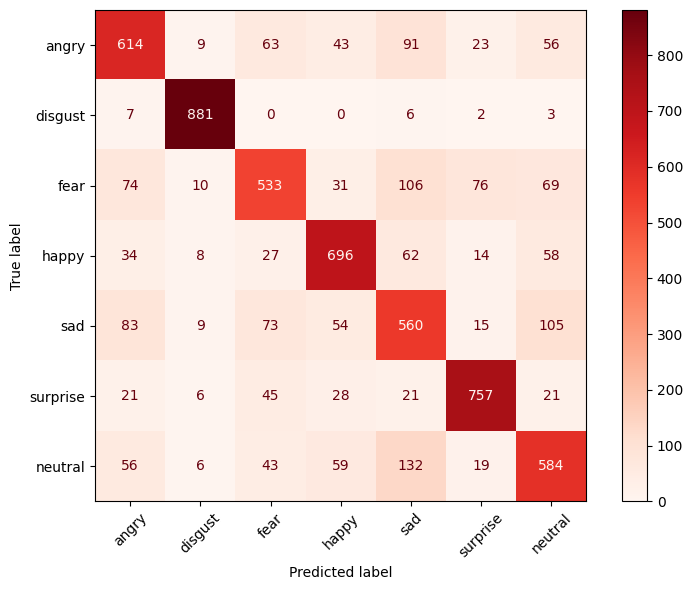

              precision    recall  f1-score   support

           0       0.69      0.68      0.69       899
           1       0.95      0.98      0.96       899
           2       0.68      0.59      0.63       899
           3       0.76      0.77      0.77       899
           4       0.57      0.62      0.60       899
           5       0.84      0.84      0.84       899
           6       0.65      0.65      0.65       899

    accuracy                           0.73      6293
   macro avg       0.73      0.73      0.73      6293
weighted avg       0.73      0.73      0.73      6293

1770/1770 ━━━━━━━━━━━━━━━━━━━━ 271s 153ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step


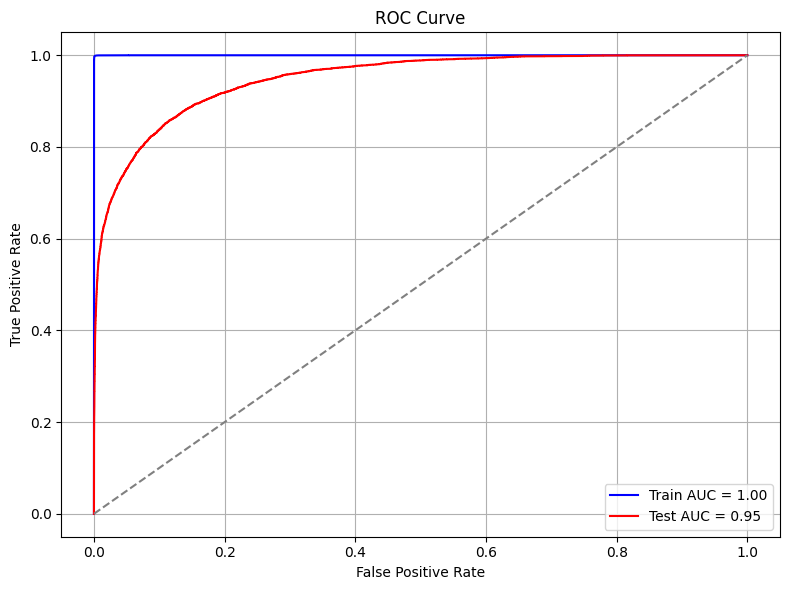

In [4]:
label_to_name = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}
conf_matrix = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[label_to_name[i] for i in range(num_classes)])
disp.plot(cmap=plt.cm.Reds, ax=ax)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.jpg', dpi=1000)
plt.show()
print(classification_report(y_true, y_pred_classes))

y_train_pred_prob = model.predict(x_train)
y_test_pred_prob = model.predict(x_test)

fpr_train, tpr_train, _ = roc_curve(y_train.ravel(), y_train_pred_prob.ravel())
fpr_test, tpr_test, _ = roc_curve(y_test.ravel(), y_test_pred_prob.ravel())

train_auc = auc(fpr_train, tpr_train)
test_auc = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', label=f'Train AUC = {train_auc:.2f}')
plt.plot(fpr_test, tpr_test, color='red', label=f'Test AUC = {test_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve.jpg', dpi=1000)
plt.show()